# Alunos

Guilherme Moreira Castilho, Pedro Santos Tokar, Vitor Matheus do Nascimento Moreira.

# Assignment 4: Fine-Tuning do Segment Anything Model (SAM)  

**Introdução:**  
O Segment Anything Model (SAM) é um modelo de segmentação altamente versátil e poderoso, desenvolvido pela Meta AI. Ele foi projetado para lidar com uma ampla gama de tarefas, como segmentar objetos específicos, regiões ou até mesmo identificar múltiplos objetos em uma única imagem sem necessidade de treinamento adicional.  

O SAM utiliza uma abordagem baseada em *prompts*, permitindo que os usuários forneçam diferentes tipos de entrada, como pontos, caixas delimitadoras ou máscaras brutas, para guiar o modelo na segmentação desejada. Ele é composto por:  
- **Encoder de Imagem:** Extrai características visuais robustas.  
- **Encoder de Prompts:** Interpreta entradas do usuário.  
- **Mask Decoder:** Gera máscaras de segmentação com alta precisão.  

Apesar de ser altamente generalista, o SAM pode ser ajustado (fine-tuned) para melhorar seu desempenho em tarefas específicas. Este processo envolve utilizar dados especializados e adaptar o modelo às necessidades de aplicações como segmentação médica, agricultura, monitoramento ambiental, entre outras.  

**Objetivo:**  
Realizar o fine-tuning do SAM para uma tarefa de segmentação específica à sua escolha, demonstrando os passos e resultados por meio de uma apresentação de 10 minutos.  

**Instruções:**  

1. **Escolha da Tarefa:**  
   Selecione uma aplicação prática de segmentação para o fine-tuning do SAM, como:  
   - Segmentação de objetos em ambientes urbanos.  
   - Identificação de características em imagens médicas.  
   - Monitoramento de mudanças em imagens de satélite.  

2. **Preparação do Dataset:**  
   - Utilize ou construa um dataset relevante para sua tarefa.  
   - Divida os dados em treino, validação e teste.  
   - Aplique técnicas de *data augmentation* caso necessário.  

3. **Adaptação do SAM:**  
   - Use o SAM pré-treinado como base.  
   - Adapte sua arquitetura para atender aos requisitos da tarefa.  
   - Decida se congelará partes do modelo ou ajustará todas as camadas.  

4. **Treinamento:**  
   - Configure parâmetros como número de épocas, taxa de aprendizado e tamanho do batch.  
   - Utilize métricas adequadas (como IoU ou Dice Coefficient) para avaliar o desempenho do modelo ajustado.  

5. **Análise e Resultados:**  
   - Compare os resultados do modelo original (pré-treinado) com o modelo ajustado (fine-tuned).  
   - Destaque os desafios enfrentados e as soluções adotadas durante o fine-tuning.  

6. **Entrega:**  
   A entrega será feita por meio de um vídeo gravado de no máximo 10 minutos, contendo:  
   - Breve introdução ao SAM e à tarefa escolhida.  
   - Explicação sobre o dataset e adaptações feitas no modelo.  
   - Resultados e comparações entre o SAM original e o modelo ajustado.  
   - Conclusões e sugestões de melhorias ou aplicações futuras.  

**Dicas:**  
- Use a [documentação oficial do SAM](https://github.com/facebookresearch/segment-anything) como guia técnico.  
- Experimente congelar diferentes partes do modelo e observe como isso afeta o desempenho.  


# Imports e instalações

In [1]:
%pip install git+https://github.com/facebookresearch/segment-anything.git
%pip install opencv-python pycocotools matplotlib onnxruntime onnx
%pip install opendatasets

!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-431d86yh
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-431d86yh
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=5e97819893b004d021d69e65bb5733d42f67e44b9246eff916c123700b193efc
  Stored in directory: /tmp/pip-ephem-wheel-cache-u6rbfzhx/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 70.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 64.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [2]:
import torch
import kagglehub
from segment_anything import SamPredictor, sam_model_registry
import numpy as np

from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import v2
import torchvision.transforms.functional as TF
from torchvision.io import decode_image
from torch.utils.data import random_split

from matplotlib import pyplot as plt
import matplotlib.patches as patches

from tqdm import tqdm

from os.path import join
from glob import glob
import json

DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
DEVICE

'cpu'

# Dataset

In [3]:
TOOTH_DATASET_PATH = kagglehub.dataset_download("vitordonascimento/dental-dataset")
#TOOTH_DATASET_PATH = "/kaggle/input/dental-dataset"
TOOTH_DATASET_PATH

100%|██████████| 372M/372M [00:02<00:00, 170MB/s] 

Extracting files...


'/root/.cache/kagglehub/datasets/vitordonascimento/dental-dataset/versions/1'

Extraindo média e desvio padrão da base de dados

In [4]:
def get_sample_mean_and_std_ds(dataset_path, image_type="jpg", device=DEVICE):
    data = glob(join(dataset_path, "*." + image_type))

    N = len(data)

    means_sum = torch.zeros(3)
    stds_sum = torch.zeros(3)

    for i in tqdm(range(N)):
        image = decode_image(data[i]).to(torch.float).to(device)
        means_sum += torch.tensor([image[0].mean(), image[1].mean(), image[2].mean()]).to(torch.float)
        stds_sum += torch.tensor([image[0].std(), image[1].std(), image[2].std()]).to(torch.float)

    return means_sum / N, stds_sum / N

#DS_MEAN, DS_STD = get_sample_mean_and_std_ds(join(TOOTH_DATASET_PATH, "dental-dataset", "adult", "images"), device = "cpu")
DS_MEAN, DS_STD = torch.tensor([95.6162, 95.6162, 95.6162]), torch.tensor([41.6408, 41.6408, 41.6408])
DS_MEAN, DS_STD

(tensor([95.6162, 95.6162, 95.6162]), tensor([41.6408, 41.6408, 41.6408]))

Classe para o Augmentation

In [ ]:
class Augmentation:
    def __init__(self, flip_prob=0.5, rotate_prob=0.5, translade_prob=0.5, change_quality_prob=0.3):
        self._flip_prob = flip_prob
        self._rotate_prob = rotate_prob
        self._apply_prob = change_quality_prob
        self._translade_prob = translade_prob

    def apply(self, image, mask):
        augment_list = list()

        if np.random.rand() < self._flip_prob:
            augment_list.append(lambda img, msk: (TF.hflip(img), TF.hflip(msk)))

        if np.random.rand() < self._translade_prob + 1:
            prop_x = float(np.random.choice(np.arange(-5, 5.5, 0.5))) / 100
            prop_y = float(np.random.choice(np.arange(-5, 5.5, 0.5))) / 100

            H, W = image[0].shape
            translate_props = (int(prop_x * W), int(prop_y * H))

            augment_list.append(lambda img, msk: (TF.affine(img, 0, translate_props, 1, (0, 0)), TF.affine(msk, 0, translate_props, 1, (0, 0))))

        if np.random.rand() < self._rotate_prob:
            angle = int(np.random.choice(np.arange(-5, 6)))
            augment_list.append(lambda img, msk: (TF.rotate(img, angle), TF.rotate(msk, angle)))


        if len(augment_list) < 1:
            augment_list.append(lambda x, y: (x, y))

        image, mask = v2.Compose(augment_list)(image, mask)

        image = v2.RandomApply([
            v2.ColorJitter(brightness=0.1, contrast=0.1),
            v2.GaussianBlur(kernel_size=3)
        ], p=self._apply_prob)(image)

        return image, mask

    def __call__(self, image, mask):
        return self.apply(image, mask)

Classe para carregar o dataset

In [ ]:
def get_bounding_box(gt_mask):
    if not torch.any(gt_mask):
        return np.array([0,0,1,1])
    y_indices, x_indices = torch.where(gt_mask > 0)
    x_min, x_max = torch.min(x_indices), torch.max(x_indices)
    y_min, y_max = torch.min(y_indices), torch.max(y_indices)

    H, W = gt_mask.shape
    x_min = max(0, x_min - np.random.randint(0, 20))
    x_max = min(W, x_max + np.random.randint(0, 20))
    y_min = max(0, y_min - np.random.randint(0, 20))
    y_max = min(H, y_max + np.random.randint(0, 20))
    bbox = np.array([x_min, y_min, x_max, y_max])

    return bbox

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, dataset="adult", dataset_path=TOOTH_DATASET_PATH, image_size=None, normalize=False, augment=None, device=DEVICE):

        self._path_data = join(dataset_path, "dental-dataset", dataset, "images")
        self._path_masks = join(dataset_path, "dental-dataset", dataset, "masks")

        self.data = glob(join(self._path_data, "*.jpg"))

        self.device = device

        if image_size:
            self.resize_image = v2.Resize(size=image_size, interpolation=v2.InterpolationMode.BILINEAR, antialias=True)
            self.resize_mask = v2.Resize(size=image_size, interpolation=v2.InterpolationMode.NEAREST)
        else:
            self.resize_image = lambda x: x
            self.resize_mask = lambda x: x

        self.normalize_image = v2.Compose([v2.ToDtype(torch.float),
                                           v2.Normalize(DS_MEAN, DS_STD),
                                           lambda x : torch.clamp(x, 0.0, 1.0)]) if normalize else lambda x: x

        self.augment = augment if augment else lambda x, y: (x, y)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        image_path = self.data[index]
        name = image_path.split("/")[-1].split(".")[0]
        mask_path = join(self._path_masks, f"{name[:-3]}mask.png")

        image = decode_image(image_path).to(self.device)
        mask = decode_image(mask_path).to(torch.float) / 255.0

        image = self.resize_image(image)
        mask = self.resize_mask(mask)

        image, mask = self.augment(image, mask)
        image = self.normalize_image(image)

        mask = self.resize_mask(mask)
        #Por algum motivo algumas vem com 1 canal e outras com 3
        if mask.shape[0] != 1:
            mask = mask[0].unsqueeze(0)

        bbox = get_bounding_box(mask[0, :])

        return image, mask, bbox

    def orig_image(self, index):
        image_path = self.data[index]
        return decode_image(image_path)

Função para fazer split do dataset

In [ ]:
def get_train_test_split(dataset, test_prop=0.2):
    n_features = len(dataset)

    test_size = round(n_features * test_prop)
    train_size = n_features - test_size

    return random_split(dataset, [train_size, test_size])

1328 443 443


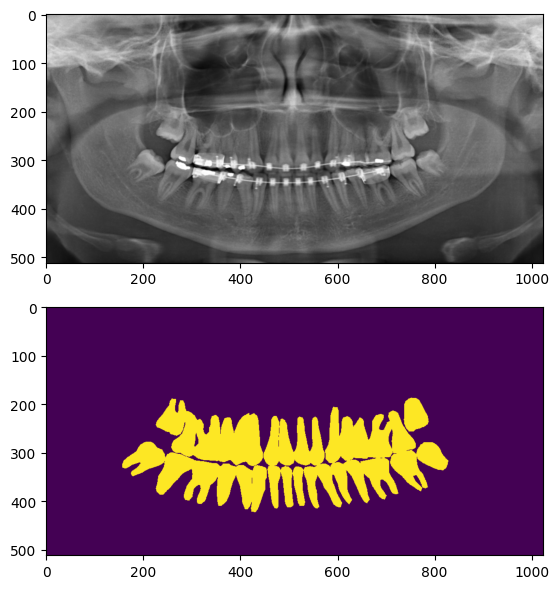

In [9]:
# Exemplo de uso do dataset com split
data = SegmentationDataset(image_size = [512, 1024], normalize = False, device = "cpu")

ds_train, ds_test = get_train_test_split(data)
ds_train, ds_val = get_train_test_split(ds_train, 1/4)

print(len(ds_train), len(ds_val), len(ds_test))

for i in range(2):
    imgs_train, masks_train = ds_train[i][:2]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

axes[0].imshow(imgs_train.permute(1, 2, 0).to("cpu"))
axes[1].imshow(masks_train[0].to("cpu"))
plt.tight_layout()

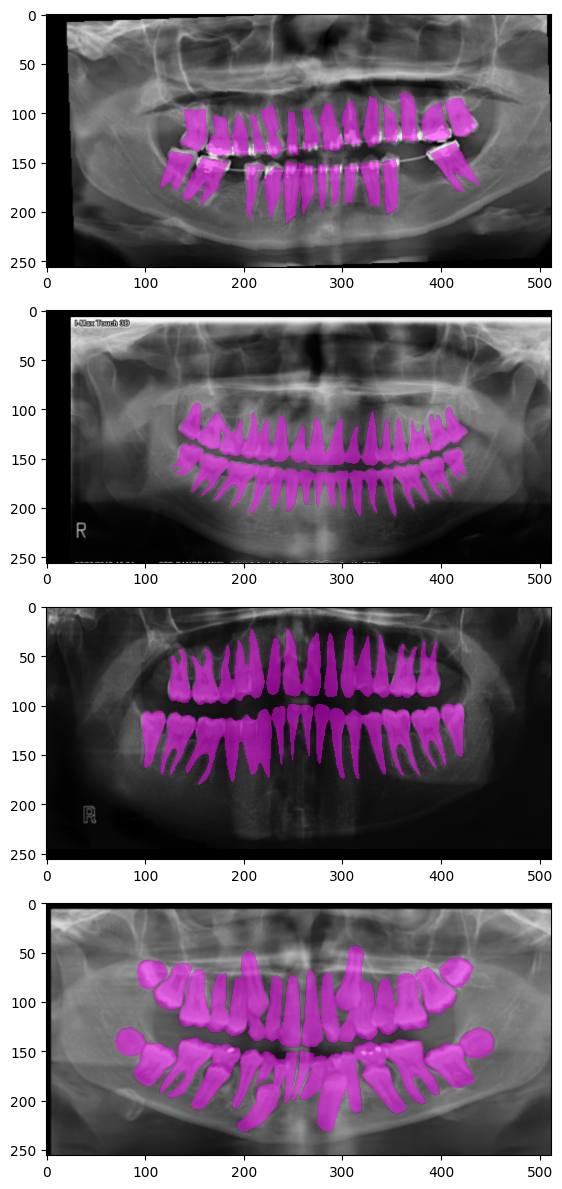

In [10]:
# Exemplo de uso do dataset com augmentation
data_aug = SegmentationDataset(image_size=[256, 512], normalize=False, augment=Augmentation(), device="cpu")

ds_train_aug, ds_test_aug = get_train_test_split(data_aug)

fig, axes = plt.subplots(4, 1, figsize=(6, 12))
for i in range(4):
    imgs_train, masks_train, bbox = ds_train_aug[i]

    axes[i].imshow(imgs_train.permute(1, 2, 0))
    masked_overlay = np.ma.masked_where(masks_train[0] == 0, masks_train[0])
    axes[i].imshow(masked_overlay, cmap = "spring", alpha = 0.5)

plt.tight_layout()

# Modelo SAM

In [11]:
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"

In [12]:
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(DEVICE)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [13]:
#Função auxiliar para plotar outputs do SAM e comparar com a ground truth

def plot_model_preds(model_output, image, ground_truth, *, box=None, points_and_labels=None):
    if torch.max(image) <= 1.0:
        image *= 255.0

    masks, confidences, _ = model_output
    number_masks = masks.shape[0] + 1

    fig, axes = plt.subplots(number_masks, 1, figsize = (6, number_masks * 3))

    axes[0].set_title("Ground Truth")
    axes[0].imshow(image.permute(1, 2, 0).to(torch.uint8))
    masked_overlay = np.ma.masked_where(ground_truth[0] == 0, ground_truth[0])
    axes[0].imshow(masked_overlay, cmap = "spring", alpha = 0.5)

    for i in range(1, number_masks):
        axes[i].set_title(f"pred {i - 1} | Confidence: {confidences[i - 1]}")
        axes[i].imshow(image.permute(1, 2, 0).to(torch.uint8))
        masked_overlay = np.ma.masked_where(masks[i - 1] == 0, masks[i - 1])
        axes[i].imshow(masked_overlay, cmap = "spring", alpha = 0.5)

        if isinstance(box, np.ndarray):
            rect = patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=1, edgecolor="#0f0", facecolor="none",
                alpha=1.0
            )
            axes[i].add_patch(rect)

        if isinstance(points_and_labels, tuple):
            points, labels = points_and_labels
            axes[i].scatter(points[labels==1][:, 0], points[labels==1][:, 1], color="#0f0")
            axes[i].scatter(points[labels==0][:, 0], points[labels==0][:, 1], color="#f00")

    plt.tight_layout()

In [14]:
#Imagens usadas para testar output do modelo
test_image, test_label, test_bbox = ds_train[0]

#Cria um predictor e define a imagem pra fazer ot este
predictor = SamPredictor(sam)
predictor.set_image(test_image.permute(1, 2, 0).numpy())

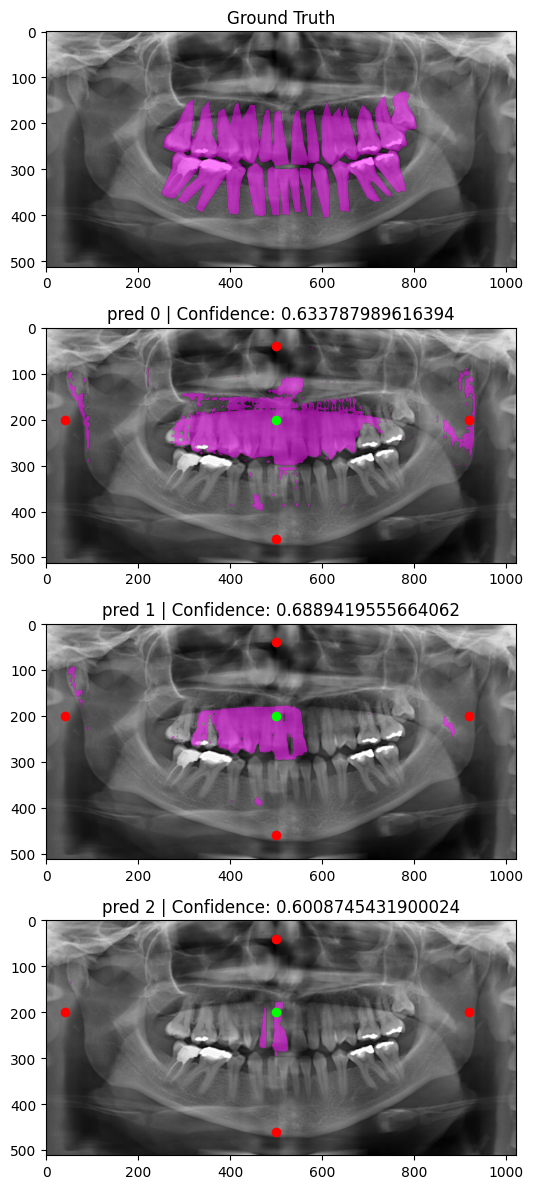

In [15]:
#Faz um teste usando um prompt de ponto
prompt_points = np.array(
    ((500, 200),
     (500, 40),
     (500, 460),
     (40, 200),
     (920, 200))
)
prompt_labels = np.array((1, 0, 0, 0, 0))
output = predictor.predict(point_coords = prompt_points, point_labels = prompt_labels)

plot_model_preds(output, test_image, test_label, points_and_labels=(prompt_points, prompt_labels))

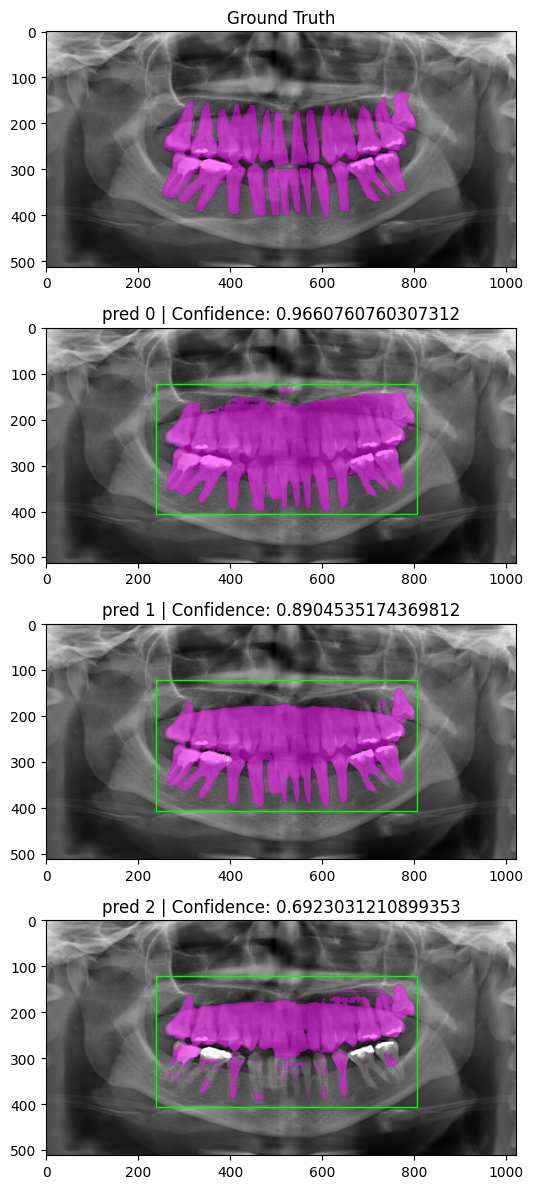

In [16]:
#Faz um teste usando um prompt de caixa
prompt_box = np.array((100, 100, 900, 400))
output = predictor.predict(box = test_bbox)

plot_model_preds(output, test_image, test_label, box=test_bbox)

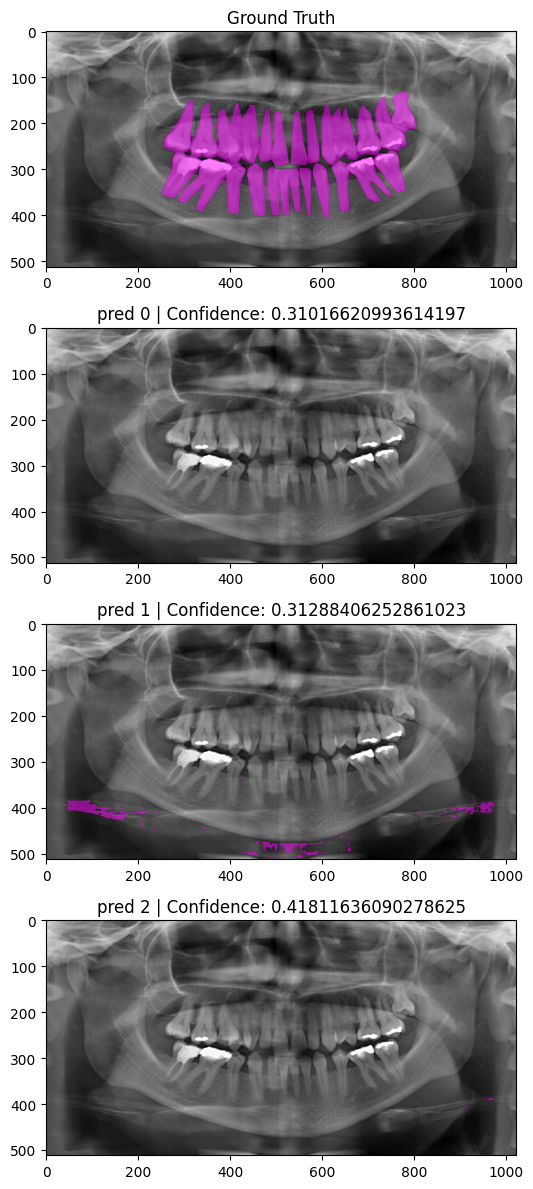

In [17]:
#Faz um teste sem usar prompt
output = predictor.predict()

plot_model_preds(output, test_image, test_label)

# Testes com avaliação

## Avaliar o modelo - sem paralelismo

In [ ]:
def masks_IoU(predicted_mask, ground_truth):
    ground_truth = (ground_truth > 0)
    predicted_mask = (predicted_mask > 0)

    intersection = (ground_truth & predicted_mask).sum().float()
    union = (ground_truth | predicted_mask).sum().float()

    IoUs = intersection / (union + 1e-6)
    return IoUs

In [ ]:
def masks_dice_coefficient(predicted_mask, ground_truth):
    ground_truth = (ground_truth > 0)
    predicted_mask = (predicted_mask > 0)

    intersection = (ground_truth & predicted_mask).sum().float()
    dice_coefficient = (2 * intersection)/(ground_truth.sum() + predicted_mask.sum() + 1e-6)
    return dice_coefficient

In [ ]:
IoUs = []
dice_coefficients = []

for image, ground_truth, bbox in tqdm(ds_test):
    predictor.set_image(image.permute(1, 2, 0).numpy())
    prompt_box = np.array((100, 100, 900, 400))
    prompt_box = bbox
    output = predictor.predict(box = prompt_box)

    most_confident_index = output[1].argmax()
    predicted_mask = output[0][most_confident_index]
    IoUs.append(masks_IoU(predicted_mask, ground_truth))
    dice_coefficients.append(masks_dice_coefficient(predicted_mask, ground_truth))

IoUs = np.array(IoUs)
dice_coefficients = np.array(dice_coefficients)

## Avaliar o modelo - com paralelismo

In [18]:
def masks_IoU(predicted_mask, ground_truth):
    N = predicted_mask.shape[0]
    ground_truth = (ground_truth > 0).view(N, -1)
    predicted_mask = (predicted_mask > 0).view(N, -1)

    intersection = (ground_truth & predicted_mask).sum(dim=1).float()
    union = (ground_truth | predicted_mask).sum(dim=1).float()

    IoUs = intersection / (union + 1e-6)
    return IoUs

In [19]:
def masks_dice_coefficient(predicted_mask, ground_truth):
    N = predicted_mask.shape[0]
    ground_truth = (ground_truth > 0).view(N, -1)
    predicted_mask = (predicted_mask > 0).view(N, -1)

    intersection = (ground_truth & predicted_mask).sum(dim=1).float()
    dice_coefficient = (2 * intersection)/(ground_truth.sum(dim=1) + predicted_mask.sum(dim=1) + 1e-6)
    return dice_coefficient

In [20]:
def sam_collate_fn(batch):
    batch_input = []
    batch_ground_truth = []

    for image, ground_truth, box in batch:
        input_dict = {
            'image': image.to(DEVICE).to(torch.float),
            'boxes': torch.tensor(box).to(DEVICE).unsqueeze(0),
            'original_size': [512, 1024]
        }
        batch_input.append(input_dict)
        batch_ground_truth.append(ground_truth)
    return batch_input, torch.stack(batch_ground_truth).to(DEVICE)

In [21]:
dataloader = DataLoader(ds_test, batch_size = 5, shuffle = True, collate_fn=sam_collate_fn)
for par in dataloader:
    print(len(par[0]))
    print(par[1].shape)
    break

5
torch.Size([5, 1, 512, 1024])


In [22]:
IoUs = []
dice_coefficients = []

with torch.no_grad():
    for batch_input, batch_ground_truth in tqdm(dataloader):
        batch_output = sam(batch_input, multimask_output = True)

        output_masks = torch.stack([output["masks"][0][0] for output in batch_output])

        IoUs.append(masks_IoU(output_masks, batch_ground_truth))
        dice_coefficients.append(masks_dice_coefficient(output_masks, batch_ground_truth))

IoUs = torch.cat(IoUs).flatten()
dice_coefficients = torch.cat(dice_coefficients).flatten()

100%|██████████| 89/89 [03:14<00:00,  2.19s/it]


## Plotar resultados

In [23]:
print(IoUs.mean())

tensor(0.6034, device='cuda:0')


Text(0.5, 0, 'IoU')

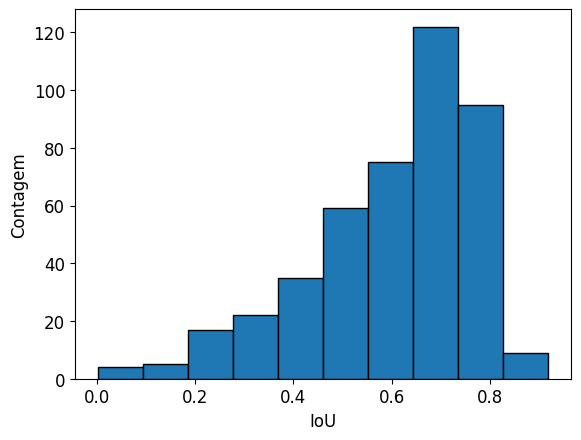

In [27]:
plt.rcParams["patch.edgecolor"] = "black"
plt.rcParams["patch.linewidth"] = 1
plt.rcParams["patch.force_edgecolor"] = True
plt.rcParams["axes.labelsize"] = "large"
plt.rcParams["xtick.labelsize"]  = "large"
plt.rcParams["ytick.labelsize"]  = "large"

plt.hist(IoUs.detach().cpu().numpy())
plt.ylabel("Contagem")
plt.xlabel("IoU")

In [28]:
print(dice_coefficients.mean())

tensor(0.7363, device='cuda:0')


Text(0.5, 0, 'Dice Coefficients')

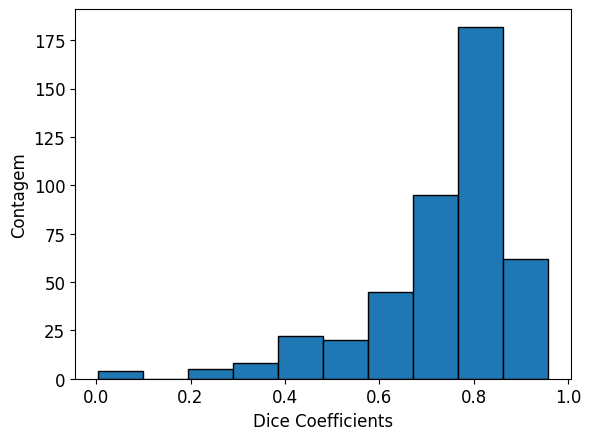

In [30]:
plt.hist(dice_coefficients.detach().cpu().numpy())
plt.ylabel("Contagem")
plt.xlabel("Dice Coefficients")

# Treino

In [ ]:
class Trainer():
    def __init__(self, model, optimizer, criterion, device):
        self._model = model
        self._optimizer = optimizer
        self._criterion = criterion
        self._device = device


        self.history = {
            "epochs": 0,
            "train_loss": [],
            "val_loss": []
        }

    def _prepare_batch_input(self, images, bboxes, original_sizes):
        batched_input = []
        for i in range(len(images)):
            dict_input = {
                "image": images[i],
                "boxes": bboxes[i].unsqueeze(0),
                "original_size": original_sizes[i]
            }
            batched_input.append(dict_input)
        return batched_input

    def train_one_epoch(self, train_loader, epoch):
        self._model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1} | Training")

        #Esse for loop é por batch, recebe tanto as imagens quanto as
        #máscaras reais em tensores com a primeira dimensão de batch
        for i, (images, gt_masks, boxes) in enumerate(progress_bar):
            self._optimizer.zero_grad()

            gt_masks = gt_masks.to(self._device)
            images = self._model.preprocess(images.to(self._device)) #faz padding das imagens e normaliza tb

            #Calculo os embeddings das imagens em batch, pra ser mais eficiente. Não precisa
            #de gradiente pq não vamos treinar o encoder e sim o mask decoder.
            with torch.no_grad():
                image_embeddings = self._model.image_encoder(images)

            loss = 0.0
            #Essa etapa precisa ser feita para cada datapoint individualmente, infelizmente
            for j, (embedding, gt_mask, box) in enumerate(zip(image_embeddings, gt_masks, boxes)):

                #Precisa fazer os embeddings da caixa que vem com o dataset. Não precisa de gradientes
                with torch.no_grad():
                    sparse_embeddings, dense_embeddings = self._model.prompt_encoder(
                        points = None,
                        masks = None,
                        boxes = torch.tensor(box).to(self._device).view(1, 1, 4)#.expand(images.shape[0], -1, -1)
                    )

                #Com o embedding das querys e das imagens, faz o cálculo das máscaras.
                #Essa é a etapa que eu quero treinar
                low_res_masks, iou_predictions = self._model.mask_decoder(
                    image_embeddings = embedding.unsqueeze(0), # (1, 256, 64, 64)
                    image_pe = self._model.prompt_encoder.get_dense_pe(), #encodings posicionais
                    sparse_prompt_embeddings = sparse_embeddings,
                    dense_prompt_embeddings = dense_embeddings,
                    multimask_output = False,
                )

                h_gt, w_gt = gt_mask.shape[-2], gt_mask.shape[-1]

                #A saída é sempre 256 por 256, dou resize pro tamanho da iamgem. Esse crop é
                #porque a imagem original entrou com padding
                pred_mask = F.interpolate(
                    low_res_masks[:, :, :128, :],
                    size = (h_gt, w_gt),
                    mode = "bilinear",
                    align_corners = False
                ).squeeze(0)

                loss += self._criterion(pred_mask.float(), gt_mask.float())

            loss = loss / gt_masks.shape[0]

            loss.backward()
            self._optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix(loss=running_loss / (i + 1))

        epoch_loss = running_loss / len(train_loader)
        return epoch_loss

    def validate_one_epoch(self, val_loader, epoch):
        self._model.eval()

        running_loss = 0.0
        progress_bar = tqdm(val_loader, desc=f"Epoch {epoch + 1} | Validation")

        with torch.no_grad():
            for i, (images, gt_masks, boxes) in enumerate(progress_bar):
                gt_masks = gt_masks.to(self._device)
                images = self._model.preprocess(images.to(self._device))

                image_embeddings = self._model.image_encoder(images)

                loss = 0.0
                for j, (embedding, gt_mask, box) in enumerate(zip(image_embeddings, gt_masks, boxes)):

                    sparse_embeddings, dense_embeddings = self._model.prompt_encoder(
                        points = None,
                        masks = None,
                        boxes = torch.tensor(box).to(self._device).view(1, 1, 4)#.expand(images.shape[0], -1, -1)
                    )

                    low_res_masks, iou_predictions = self._model.mask_decoder(
                        image_embeddings=embedding.unsqueeze(0),
                        image_pe=self._model.prompt_encoder.get_dense_pe(),
                        sparse_prompt_embeddings=sparse_embeddings,
                        dense_prompt_embeddings=dense_embeddings,
                        multimask_output=False,
                    )

                    h_gt, w_gt = gt_mask.shape[-2], gt_mask.shape[-1]

                    pred_mask = F.interpolate(
                        low_res_masks[:, :, :128, :],
                        size=(h_gt, w_gt),
                        mode="bilinear",
                        align_corners=False
                    ).squeeze(0)

                    loss += self._criterion(pred_mask.float(), gt_mask.float())

                loss = loss / gt_masks.shape[0]
                running_loss += loss.item()
                progress_bar.set_postfix(val_loss=running_loss / (i + 1))

        epoch_loss = running_loss / len(val_loader)
        return epoch_loss

    def save_model(self, path = None):
        if path:
            json_path = join(*path, f"{self.__class__.__name__}.json")
            pth_path = join(*path, f"{self.__class__.__name__}.pth")
        else:
            json_path = f"{self.__class__.__name__}.json"
            pth_path = f"{self.__class__.__name__}.pth"
        with open(json_path, "w", encoding = "utf-8") as f:
            json.dump(self.history, f, ensure_ascii = False, indent = 4)
        torch.save(self._model.state_dict(), pth_path)

    def load_model(self, path = None, name = None):
        name = name if name else self.__class__.__name__
        if path:
            json_path = join(*path, f"{name}.json")
            pth_path = join(*path, f"{name}.pth")
        else:
            json_path = f"{name}.json"
            pth_path = f"{name}.pth"
        with open(json_path, "r", encoding = "utf-8") as f:
            self.history = json.load(f)
        self.load_state_dict(torch.load(pth_path, map_location=torch.device(DEVICE), weights_only = True))

    def fit(self, train_loader, val_loader, num_epochs, scheduler = None):
        val_loss = np.inf
        for epoch in range(self.history["epochs"], self.history["epochs"] + num_epochs):
            val_loss_prev = val_loss

            train_loss = self.train_one_epoch(train_loader, epoch)

            print(f"Fim Epoch {epoch+1}:")
            print(f"   -> Loss train: {train_loss:.3f}")
            if scheduler:
                scheduler.step(train_loss)
                print(f"   -> LR: {scheduler.get_last_lr()[0]:.6f}\\n")

            self.history["epochs"] = epoch
            self.history["train_loss"].append(train_loss)

            if val_loader:
                val_loss = self.validate_one_epoch(val_loader, epoch)
                print(f"   -> Loss val: {val_loss:.3f}")
                self.history["val_loss"].append(val_loss)

                #Early Stop
                if val_loss > val_loss_prev + 0.2:
                    self.save_model()
                    break

            if epoch % 5 == 0:
                self.save_model()



        return self.history

In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        inputs_prob = torch.sigmoid(inputs)

        intersection = (inputs_prob * targets).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs_prob.sum() + targets.sum() + smooth)

        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='mean')

        return dice_loss + bce

In [ ]:
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(DEVICE)

for param in sam.image_encoder.parameters():
    param.requires_grad = False

for param in sam.prompt_encoder.parameters():
    param.requires_grad = False

for param in sam.mask_decoder.parameters():
    param.requires_grad = True


optimizer = optim.NAdam(sam.mask_decoder.parameters(), lr=0.001)

criterion = DiceBCELoss()
trainer = Trainer(sam, optimizer, criterion, DEVICE)

data = SegmentationDataset(image_size = [512, 1024], normalize = False, device = "cpu")

ds_train, ds_test = get_train_test_split(data)
ds_train, ds_val = get_train_test_split(ds_train, 1/4)

train_loader = DataLoader(ds_train, batch_size=3)
val_loader = DataLoader(ds_val, batch_size=3) #, collate_fn=sam_collate_fn)

trainer.fit(train_loader, val_loader, num_epochs=100)